# 00 — Sanity Check
Verifica ambiente: PyTorch, MPS, NumPy/Pandas/Matplotlib, scikit-learn.

In [1]:
import sys, platform
print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
try:
    import torch, torchvision, torchaudio
    print("torch:", torch.__version__)
    print("torchvision:", torchvision.__version__)
    print("torchaudio:", torchaudio.__version__)
except Exception as e:
    print("PyTorch non disponibile:", e)


Python: 3.12.11
OS: Linux-6.10.14-linuxkit-aarch64-with-glibc2.41
PyTorch non disponibile: libgomp.so.1: cannot open shared object file: No such file or directory


In [2]:
import torch
mps_ok = torch.backends.mps.is_available()
print("MPS disponibile:", mps_ok)
device = torch.device("mps" if mps_ok else "cpu")
x = torch.rand(2,3, device=device)
y = torch.randn(2,3, device=device)
z = x + y
print("Tensor OK su", device, "| shape:", z.shape)


MPS disponibile: False
Tensor OK su cpu | shape: torch.Size([2, 3])


In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({"x": np.linspace(0, 10, 100)})
df["y"] = np.sin(df["x"])
df.head()


,x,y
0,0.00000,0.000000
1,0.10101,0.100838
2,0.20202,0.200649
3,0.30303,0.298414
4,0.40404,0.393137


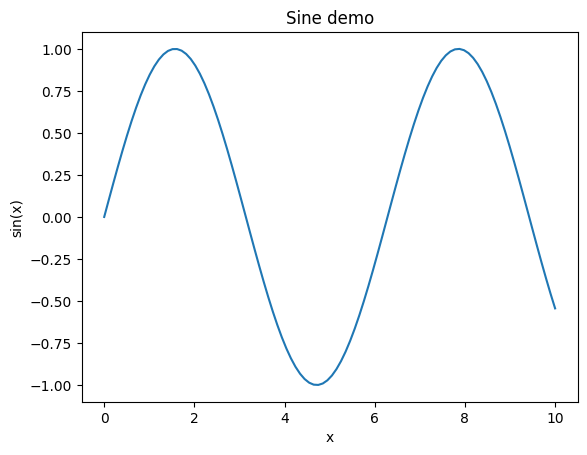

In [4]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(df["x"], df["y"])
plt.title("Sine demo")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.show()


In [5]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=500, n_features=10, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
pred = clf.predict(Xte)
print("Accuracy:", round(accuracy_score(yte, pred), 3))


Accuracy: 0.864
